# Sources:
0. install kestra by docker: https://www.youtube.com/watch?v=bQNmXge5vSY

1. Build your first workflow with kestra (logout, use python, pass task output to another task): https://www.youtube.com/watch?v=bQNm

2. https://www.youtube.com/watch?v=xnGYiWFM2uk
if we have S3 bucket that contains CSV file periodically that we need to get into Google sheet so you canperform calculations. We can use the S3 trigger to listen for new files and run the flow ASA they arrive. Then we can upload it to Google sheet and we can also add notification to know that the file is arrived to Google sheet.
We can also set the variable 
- variables, then in the task we get them this mean we can store the variable as input then we call them in different tasks
We can also pass the data to postgressql, we create table,then loading and pasing that new file.

# Agent
3. Agent:: https://www.youtube.com/watch?v=7tvpR8EE0gs&list=PL3MmuxUbc_hLZFNgSad56pDBKK8KO0XIv

Use AI Agents when the exact sequence of steps isn't known in advance, decisions depend on dynamic changing information, or you need to adapt to unexpected conditions.

Use traditional workflows when steps are deterministic and repeatable, compliance requires exact auditable processes, or cost and latency must be minimized.

AI Agent Workflow — agent decides what to do, in what order, based on the goal:

tasks:
  - id: agent
    type: io.kestra.plugin.ai.agent.AIAgent
    prompt: "Research data engineering trends and create a report"
    tools:
      - WebSearch
      - TaskExecution


id: example_agent
namespace: zoomcamp

tasks:
  - id: agent
    type: io.kestra.plugin.ai.agent.AIAgent

    # Defines the agent's role and behavior
    systemMessage: |
      You are a data analyst. Analyze data and provide insights.

    # The actual task or question
    prompt: "What are the top 3 trends in this data?"

    # LLM provider configuration
    provider:
      type: io.kestra.plugin.ai.provider.GoogleGemini
      modelName: gemini-2.5-flash
      apiKey: "{{ secret('GEMINI_API_KEY') }}"

    # Tools the agent can use
    tools:
      - type: io.kestra.plugin.ai.tool.TavilyWebSearch
        apiKey: "{{ secret('TAVILY_API_KEY') }}"

    # Memory for context across executions
    memory:
      type: io.kestra.plugin.ai.memory.KestraKVStore
      memoryId: analyst_001

# Agent with tools (Web Search, tavily  and filessystem tool MCP)

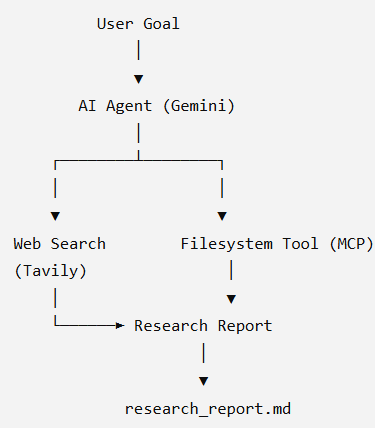

In [ ]:
id: 5_web_research_agent
namespace: zoomcamp

description: |
  This flow demonstrates an advanced AI agent that uses tools autonomously.
  The agent:
  - Decides when to use the web search tool
  - Gathers information from multiple sources
  - Synthesizes findings into a structured report
  - Saves the output as a markdown file
  Key concept: You specify the GOAL, the agent decides HOW to achieve it.

inputs:
  - id: research_topic  # you will receive a topic to search, by default::: Research the latest trends in data orchestration and workflow automation.
    type: STRING
    displayName: Research Topic
    defaults: |
      Research the latest trends in data orchestration and workflow automation.
      Include information about:
      - Popular tools and platforms
      - Emerging patterns (e.g., AI-driven orchestration)
      - Key challenges in the space
      - Recent innovations

tasks:
  - id: research_agent
    type: io.kestra.plugin.ai.agent.AIAgent
    description: Autonomous research agent with web search capabilities
    provider:
      type: io.kestra.plugin.ai.provider.GoogleGemini
      apiKey: "{{ secret('GEMINI_API_KEY') }}"
      modelName: gemini-2.5-flash
    prompt: "{{ inputs.research_topic }}"
    systemMessage: |
      You are a thorough research assistant. Follow this process:
      1. Use the TavilyWebSearch content retriever to gather up-to-date information on the topic. Search multiple times if needed to get comprehensive coverage.
      2. Evaluate the search results and determine if you have enough information. If not, search again with refined queries.
      3. Synthesize your findings into a well-structured Markdown report with:
         - Executive Summary (2-3 sentences)
         - Key Findings (3-5 bullet points)
         - Detailed Analysis (2-3 paragraphs)
         - Sources (list URLs of key references)
      4. Save the final report as 'research_report.md' in the /tmp directory
         using the filesystem tool.
      Important rules:
      - Always use the TavilyWebSearch content retriever to get current information
      - Do not make up or hallucinate information
      - Include specific examples and data points when available
      - Always save the final report to research_report.md using the filesystem tool.
    contentRetrievers:
      - type: io.kestra.plugin.ai.retriever.TavilyWebSearch
        apiKey: "{{ secret('TAVILY_API_KEY') }}"
        maxResults: 10
    tools:
      - type: io.kestra.plugin.ai.tool.DockerMcpClient  # it is like USB for AI model, 
        image: mcp/filesystem # This launches a Docker container that exposes an MCP server. The agent can say things like; create file, write file, read file, list files
        command: ["/tmp"] # It tells the filesystem MCP server: Only allow access inside /tmp. So the agent cannot browse your whole computer. It only has access to that mounted directory.
        binds: ["{{workingDir}}:/tmp"] # This mounts Kestra's working directory into the MCP container; Kestra folder -> docker mcp filesysytem -> research_report.md Note:: Without the bind mount, the report would stay inside the temporary container and Kestra wouldn't be able to retrieve it.
    outputFiles:
      - research_report.md  # After the agent saves the report, Kestra copies it into the workflow outputs so later tasks can use it.

  - id: log_report
    type: io.kestra.plugin.core.log.Log
    message: |
      ✅ Research completed!
      📄 Report saved to: {{ outputs.research_agent.outputFiles['research_report.md'] }}
      🔍 Agent made autonomous decisions about:
      - Which searches to perform
      - How many searches were needed
      - How to structure the report
      - When the task was complete
      📊 Token usage: {{ outputs.research_agent.tokenUsage.totalTokenCount }} tokens
      💡 This demonstrates the power of AI agents: you specified the GOAL, 
         the agent figured out the HOW!

### multi agenrts (note::: we can put human in a loop, and wr can also send email)

id: 6_multi_agent_research
namespace: zoomcamp

description: |
  This flow demonstrates a multi-agent system where specialized agents collaborate.
  Architecture:
  - Main Agent (Analyst): Synthesizes findings and creates structured reports (this agent receives information, and decides what is immpotant, what should be included, how should the JSON look). Ti is the senior consultant
  - Research Agent (Tool): Gathers web data using Tavily search (this agen only find information). It does not build the final report, it does not format JSON, it does not think about competitors unless asked, so his job simply question then he search by tavily then he returns the facts
  The main agent uses the research agent as a TOOL, demonstrating how agents can delegate specialized work to other agents. # Note we could have main agent that has::: research agent, sql agent, coding agent, finance agent, email agent, filesysytem agent each one is an expert, the  main agent becomes a manager

inputs:
  - id: company_name
    type: STRING
    description: The company to research
    defaults: kestra.io

tasks:
  - id: analysis
    type: io.kestra.plugin.ai.agent.AIAgent
    description: Main analyst agent that orchestrates research
    configuration:
      logRequests: false # this control kestra behaviour, if True then kestra logs the system and also the prompt, if false then kestra does not log it
      logResponses: false # this control kestra behaviour  if True, then kestra stores the raw response in the logs, if false kestra store only the answer
    provider:
      type: io.kestra.plugin.ai.provider.GoogleGemini
    systemMessage: |
      You are a senior market intelligence analyst. You can use the research tool to gather accurate, up-to-date company data. 
      After retrieving information, summarize and synthesize it into structured, factual insights.
      If information is incomplete, infer from context or industry knowledge, but never leave required fields empty.
      Output must be a **valid JSON object only** — without markdown, code fences, or commentary.
      Never include ```json or ``` markers.
    prompt: |
      Research the company "{{ inputs.company_name }}" using the research tool.
      Then summarize your findings in this JSON structure:

      {
        "company": "string — name of the company",
        "summary": "string — overview of what the company does and its main products or services",
        "recent_news": [
          {
            "title": "string — short headline or topic",
            "date": "string — publication date or approximate timeframe",
            "description": "string — short summary of the news item"
          }
        ],
        "competitors": ["string — list of notable competitors or similar companies"]
      }

      Rules:
      - Do **not** use markdown or code fences in your response.
      - Always output a single valid JSON object.
      - Always include at least two `recent_news` entry (real or inferred) and at least two `competitors`.
      - Do **not** include explanations or commentary outside the JSON.
    tools:
      - type: io.kestra.plugin.ai.tool.AIAgent
        description: Web research and data gathering
        configuration:
          logRequests: false
          logResponses: false
        systemMessage: |
          You are a research assistant that searches the web for factual and up-to-date company information as of date {{ now() }}.
          Look for recent news from this year, funding announcements, blog posts, or competitor mentions.
          Return concise factual summaries — no markdown, no formatting, no speculation.
        provider:
          type: io.kestra.plugin.ai.provider.GoogleGemini
        contentRetrievers:
          - type: io.kestra.plugin.ai.retriever.TavilyWebSearch
            apiKey: "{{ secret('TAVILY_API_KEY') }}"

  - id: parse_results
    type: io.kestra.plugin.core.log.Log
    message: |
      🎯 Competitive Intelligence Report
      =====================================
      
      Company: {{ json(outputs.analysis.textOutput).company }}  # the agent can not create a file, so kestra does it, outputs.analysis.textOutput  is the text "{\"company\":\"Kestra\", ... }", then kestra (jinja) convert it to json (parse it to json) since it has the function JSON  . Note testoutput is the {company, .., summary:..., 
      Summary: {{ json(outputs.analysis.textOutput).summary }}
      
      Recent News: # "Take each object in the recent_news list and call it news
      {% for news in json(outputs.analysis.textOutput).recent_news %}
      - {{ news.title }} ({{ news.date }})
        {{ news.description }}
      {% endfor %}
      
      Competitors:
      {% for competitor in json(outputs.analysis.textOutput).competitors %}
      - {{ competitor }}
      {% endfor %}
      
      📊 System Performance:
      - Main agent tokens: {{ outputs.analysis.tokenUsage.totalTokenCount }}
      
      💡 Multi-Agent Pattern:
      This demonstrates how the main analyst agent delegated the research 
      work to a specialized research agent, achieving modularity and 
      separation of concerns.

pluginDefaults:
  - type: io.kestra.plugin.ai.provider.GoogleGemini
    values:
      modelName: gemini-2.5-flash
      apiKey: "{{ secret('GEMINI_API_KEY') }}"

# Kestra documentation


AI Tools Overview: https://kestra.io/docs/ai-tools
AI Copilot:https://kestra.io/docs/ai-tools/ai-copilot (this is by adding ai to kestr in the docker comose file), we can askthe AI copilot to write a flow that runs every Monday at 10 morning, 
another example:: create a flow with a python script that fetches weather data for New Yprk City,
After that we tell the Ai copilot to add trigger so that the code scedule every monday morning at 10

Then we can ask: Send a slack notification that approval is needed and Pause the flow for manual approval

Then send a post request to https://dummyjson.com/products/add


Then Run a shell command echo "hello docker" in a docker container
triggers:
  - id: every_monday_morning
    type: io.kestra.plugin.core.trigger.Schedule
    cron: "0 0 * * 1"


AI Agents:https://kestra.io/docs/ai-tools/ai-agents  (multiple agent that knows each other and different provider, redis ao maemory so that the agent remember or )
RAG Workflows: there RAG and also RAG with websearch  (https://kestra.io/docs/ai-tools/ai-rag-workflows)
AI Plugin:
AI Agent Task: https://kestra.io/plugins/plugin-ai/agent  (summarize, trigger ....)
RAG Tasks: https://kestra.io/plugins/plugin-ai/rag (chatCompletion, IngestDocument, Search) this is so important ...........................
Blueprints library: 
